# Pseudobulk method benchmark

💡 **Environment:** `clamp-analyses`  

Benchmarks all matrix factorization methods against ground-truth cell-type fractions
across pseudobulk datasets (max Pearson correlation per cell type, via a greedy
one-to-one LV -> cell-type assignment), then compares CLAMPfull against its
competitors with paired statistics (Wilcoxon signed-rank tests) and a
dataset-level bootstrap on how often it ranks first.

## Libraries

In [1]:
library(data.table)
library(ggplot2)
library(yaml)
library(here)
source(here("scripts", "pseudobulk", "common.R"))

set.seed(123)

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Configuration

In [2]:
DATASETS <- c("Brain_Mathys2023", "Brain_Xiong2023",
              "PBMC_1k1k", "PBMC_Perez2022",
              "Heart_Datar2026", "Lung_Sikkema2023")

DATA_DIR <- here("data", "pseudobulk")
MOD_ROOT <- here("output", "01_model_building", "05_pseudobulk")
OUT_DIR  <- here("output", "03_model_biology", "02_pseudobulk", "00_benchmark")
dir.create(OUT_DIR, showWarnings = FALSE, recursive = TRUE)

# Display name -> B.csv path relative to <MOD_ROOT>/<dataset>/
METHODS <- list(
  CLAMPbase  = "CLAMPbase/B.csv",
  CLAMPfull  = "CLAMPfull/B.csv",
  PLIER      = "PLIER/B.csv",
  PCA        = "PCA/B.csv",
  NMF        = "NMF/B.csv",
  ICA        = "ICA/B.csv",
  Flashier   = "flashier/B.csv",
  `MOFA-FLEX` = "MOFA_FLEX_PRIOR/B_matrix.csv",
  GSSig      = "GSS/B.csv"
)

## Scoring helpers

In [3]:
# Greedy one-to-one assignment: each LV -> at most one cell type.
# cc: n_LVs x n_cell_types correlation matrix.
# Returns a masked matrix where each row and column has at most one non-zero.
oneToOneMask <- function(cc) {
  mask <- matrix(0, nrow(cc), ncol(cc), dimnames = dimnames(cc))
  cc_work <- cc
  while (any(!is.na(cc_work) & !is.nan(cc_work))) {
    best <- which(cc_work == max(cc_work, na.rm = TRUE), arr.ind = TRUE)
    if (nrow(best) == 0) break
    r <- best[1, 1]; col <- best[1, 2]
    mask[r, col]    <- cc_work[r, col]
    cc_work[r, ]    <- NA   # LV r used
    cc_work[, col]  <- NA   # cell type col used
  }
  mask
}

# Score an LV matrix (samples x LVs) against a truth matrix (samples x cell_types).
# Returns a named numeric vector: max correlation per cell type after one-to-one
# assignment. Intentional design: once an LV is claimed by a cell type it can't
# be reused for another, so a method can't get credit for the same LV matching
# multiple cell types. When n_cell_types > n_LVs (e.g. Lung: 23 cell types vs
# CLAMPfull's k=18), some cell types will genuinely have no LV left to claim --
# that's a real, meaningful limitation of the factorization for that dataset,
# not an artifact to paper over.
score_per_ct <- function(fac, truth, ct_names) {
  shared <- intersect(rownames(fac), rownames(truth))
  if (length(shared) == 0) return(setNames(rep(NA_real_, length(ct_names)), ct_names))
  fac_s   <- fac[shared, , drop = FALSE]
  truth_s <- truth[shared, , drop = FALSE]

  fac_s <- fac_s[, apply(fac_s, 2, var, na.rm = TRUE) > 0, drop = FALSE]
  if (ncol(fac_s) == 0) return(setNames(rep(NA_real_, length(ct_names)), ct_names))

  cc  <- cor(fac_s, truth_s, method = "pearson", use = "pairwise.complete.obs")
  cc  <- oneToOneMask(cc)
  v   <- apply(cc, 2, max)
  v[!is.finite(v) | v <= -1] <- NA_real_
  setNames(v, ct_names)
}

# Same one-to-one assignment as score_per_ct, but also returns the full unmasked
# correlation matrix and per-assignment specificity margins (how much higher the
# assigned pair's correlation is than the next-best competing LV/cell type) --
# used by 01_disentangle to show related cell types map to distinct LVs.
assign_with_margins <- function(fac, truth, ct_names) {
  shared <- intersect(rownames(fac), rownames(truth))
  if (length(shared) == 0) return(list(cc = NULL, assignment = NULL))
  fac_s   <- fac[shared, , drop = FALSE]
  truth_s <- truth[shared, , drop = FALSE]
  fac_s   <- fac_s[, apply(fac_s, 2, var, na.rm = TRUE) > 0, drop = FALSE]
  if (ncol(fac_s) == 0) return(list(cc = NULL, assignment = NULL))

  cc   <- cor(fac_s, truth_s, method = "pearson", use = "pairwise.complete.obs")
  mask <- oneToOneMask(cc)

  assignment <- do.call(rbind, lapply(ct_names, function(ct) {
    if (!ct %in% colnames(mask)) return(NULL)
    col_vals <- mask[, ct]
    assigned <- which(col_vals != 0)
    if (length(assigned) == 0) return(NULL)
    lv <- rownames(mask)[assigned[1]]
    r  <- col_vals[assigned[1]]

    # Next-best LV for this cell type (excluding the assigned LV itself).
    ct_col         <- cc[, ct]
    ct_col_other   <- ct_col[names(ct_col) != lv]
    r_next_best_ct <- if (length(ct_col_other) > 0) max(ct_col_other, na.rm = TRUE) else NA_real_

    # Next-best cell type for this LV (excluding the assigned cell type itself).
    lv_row         <- cc[lv, ]
    lv_row_other   <- lv_row[names(lv_row) != ct]
    r_next_best_lv <- if (length(lv_row_other) > 0) max(lv_row_other, na.rm = TRUE) else NA_real_

    data.frame(
      cell_type      = ct,
      LV             = lv,
      cor            = r,
      r_next_best_ct = r_next_best_ct,
      r_next_best_lv = r_next_best_lv,
      margin_ct      = r - r_next_best_ct,
      margin_lv      = r - r_next_best_lv,
      stringsAsFactors = FALSE
    )
  }))

  cc_long <- as.data.frame(as.table(cc), stringsAsFactors = FALSE)
  names(cc_long) <- c("LV", "cell_type", "cor")

  list(cc = cc_long, assignment = assignment)
}

# Read B.csv -> samples x LVs (transpose from stored k x samples).
# suppressWarnings: fread warns about missing row-name header, which is expected.
read_B <- function(path) {
  dt  <- suppressWarnings(fread(path))
  mat <- as.matrix(dt[, -1, with = FALSE])
  storage.mode(mat) <- "numeric"
  rownames(mat) <- dt[[1]]
  t(mat)  # samples x LVs
}

# Read truth CSV -> samples x cell_types
read_truth <- function(path) {
  dt  <- suppressWarnings(fread(path))
  mat <- as.matrix(dt[, -1, with = FALSE])
  storage.mode(mat) <- "numeric"
  rownames(mat) <- dt[[1]]
  mat
}

## Score all methods across all datasets

In [4]:
# Cell 8 loops over every dataset/method combo, scores each method's latent variables against ground-truth cell-type fractions (via one-to-one correlation matching),
# and additionally computes CLAMPfull's LV→cell-type assignments and full correlation matrix for downstream use.

long_rows      <- list()
assign_rows    <- list()
corr_full_rows <- list()

for (ds in DATASETS) {
  message("\n========== ", ds, " ==========")
  ds_dir <- file.path(MOD_ROOT, ds)

  p0_path <- file.path(DATA_DIR, ds, "truthFrac_v0.csv")
  if (!file.exists(p0_path)) {
    message("  Truth file missing for ", ds, "; skipping.")
    next
  }
  p0    <- read_truth(p0_path)
  # For studies with <=100 samples, exclude cell types below 0.5% mean prevalence.
  if (nrow(p0) <= 100) {
    keep <- colMeans(p0, na.rm = TRUE) >= 0.005
    p0 <- p0[, keep, drop = FALSE]
  }
  ct_v0 <- colnames(p0)
  cat("  truth: v0=", length(ct_v0), "types\n")

  for (meth in names(METHODS)) {
    b_path <- file.path(ds_dir, METHODS[[meth]])
    if (!file.exists(b_path)) {
      message("  ", meth, " B.csv not found — skipping.")
      next
    }

    fac <- tryCatch(read_B(b_path), error = function(e) {
      message("  ERROR reading ", meth, ": ", conditionMessage(e)); NULL
    })
    if (is.null(fac)) next
    cat("  ", meth, " B: ", nrow(fac), "samples x", ncol(fac), "LVs\n")

    cv0 <- score_per_ct(fac, p0, ct_v0)
    long_rows <- c(long_rows, list(data.table(
      dataset   = ds, method = meth, truth = "v0",
      cell_type = names(cv0), cor = unname(cv0)
    )))

    if (meth == "CLAMPfull") {
      res <- assign_with_margins(fac, p0, ct_v0)
      if (!is.null(res$assignment)) {
        assigns <- res$assignment
        assigns$dataset <- ds
        assign_rows <- c(assign_rows, list(as.data.table(assigns)))
      }
      if (!is.null(res$cc)) {
        cc_df <- res$cc
        cc_df$dataset <- ds
        corr_full_rows <- c(corr_full_rows, list(as.data.table(cc_df)))
      }
    }
  }
}

long           <- rbindlist(long_rows,      fill = TRUE)
lv_assignments <- rbindlist(assign_rows,    fill = TRUE)
lv_corr_full   <- rbindlist(corr_full_rows, fill = TRUE)
cat("\nLong table rows:", nrow(long), "\n")
cat("CLAMPfull LV assignments:", nrow(lv_assignments), "\n")
cat("CLAMPfull full LV x cell-type correlations:", nrow(lv_corr_full), "\n")
head(long)


========== Brain_Mathys2023 ==========



  truth: v0= 6 types
   CLAMPbase  B:  80 samples x 19 LVs
   CLAMPfull  B:  80 samples x 19 LVs
   PLIER  B:  80 samples x 19 LVs
   PCA  B:  80 samples x 19 LVs
   NMF  B:  80 samples x 19 LVs
   ICA  B:  80 samples x 19 LVs
   Flashier  B:  80 samples x 19 LVs
   MOFA-FLEX  B:  80 samples x 1489 LVs
   GSSig  B:  80 samples x 5 LVs



========== Brain_Xiong2023 ==========



  truth: v0= 6 types
   CLAMPbase  B:  74 samples x 18 LVs
   CLAMPfull  B:  74 samples x 18 LVs
   PLIER  B:  74 samples x 18 LVs
   PCA  B:  74 samples x 18 LVs
   NMF  B:  74 samples x 18 LVs
   ICA  B:  74 samples x 18 LVs
   Flashier  B:  74 samples x 18 LVs
   MOFA-FLEX  B:  74 samples x 1479 LVs
   GSSig  B:  74 samples x 4 LVs



========== PBMC_1k1k ==========



...

  truth: v0= 8 types
   CLAMPbase  B:  100 samples x 18 LVs
   CLAMPfull  B:  100 samples x 18 LVs
   PLIER  B:  100 samples x 18 LVs
   PCA  B:  100 samples x 18 LVs
   NMF  B:  100 samples x 18 LVs
   ICA  B:  100 samples x 18 LVs
   Flashier  B:  100 samples x 18 LVs
   MOFA-FLEX  B:  100 samples x 1515 LVs
   GSSig  B:  100 samples x 4 LVs



Long table rows: 423 


CLAMPfull LV assignments: 47 


CLAMPfull full LV x cell-type correlations: 2166 


dataset,method,truth,cell_type,cor
<chr>,<chr>,<chr>,<chr>,<dbl>
Brain_Mathys2023,CLAMPbase,v0,Ast,0.9209964
Brain_Mathys2023,CLAMPbase,v0,Exc,0.6287725
Brain_Mathys2023,CLAMPbase,v0,Inh,0.8384232
Brain_Mathys2023,CLAMPbase,v0,Mic,0.9747729
Brain_Mathys2023,CLAMPbase,v0,Oli,0.9561039
Brain_Mathys2023,CLAMPbase,v0,Opc,0.4711528


## Summary table

In [5]:
METHOD_LEVELS <- c("CLAMPbase", "CLAMPfull", "PLIER", "PCA", "NMF", "ICA",
                   "Flashier", "MOFA-FLEX", "GSSig")
                   
long[, method := factor(method, levels = intersect(METHOD_LEVELS, unique(method)))]

summary_dt <- long[, .(
  mean_cor   = mean(cor,   na.rm = TRUE),
  median_cor = median(cor, na.rm = TRUE),
  n_ct       = .N
), by = .(dataset, method, truth)]
setorder(summary_dt, dataset, truth, -mean_cor)

cat("\n--- per-method summary ---\n")
print(summary_dt)
cat("\nCLAMPfull assignments preview:\n")
print(head(lv_assignments, 10))


--- per-method summary ---


             dataset    method  truth  mean_cor median_cor  n_ct
              <char>    <fctr> <char>     <num>      <num> <int>
 1: Brain_Mathys2023 CLAMPbase     v0 0.7983703  0.8797098     6
 2: Brain_Mathys2023 CLAMPfull     v0 0.7847413  0.8533531     6
 3: Brain_Mathys2023     PLIER     v0 0.7586873  0.8119960     6
 4: Brain_Mathys2023  Flashier     v0 0.5886090  0.5418162     6
 5: Brain_Mathys2023       NMF     v0 0.5455501  0.5114353     6
 6: Brain_Mathys2023       PCA     v0 0.5351594  0.5788838     6
 7: Brain_Mathys2023       ICA     v0 0.4514338  0.3868528     6
 8: Brain_Mathys2023 MOFA-FLEX     v0 0.3460309  0.3421985     6
 9: Brain_Mathys2023     GSSig     v0 0.2611975  0.1970777     6
10:  Brain_Xiong2023 CLAMPfull     v0 0.7803047  0.8291453     6
11:  Brain_Xiong2023 CLAMPbase     v0 0.7194099  0.7808022     6
12:  Brain_Xiong2023     PLIER     v0 0.6955302  0.7664244     6
13:  Brain_Xiong2023  Flashier     v0 0.6848775  0.7555465     6
14:  Brain_Xiong2023     


CLAMPfull assignments preview:


    cell_type     LV       cor r_next_best_ct r_next_best_lv  margin_ct
       <char> <char>     <num>          <num>          <num>      <num>
 1:       Ast   LV17 0.8911263      0.3225390     0.48450306 0.56858730
 2:       Exc   LV11 0.6028913      0.5848226     0.09751392 0.01806862
 3:       Inh    LV4 0.8155799      0.6555200     0.43420649 0.16005985
 4:       Mic    LV6 0.9655128      0.4927088     0.25219939 0.47280405
 5:       Oli   LV18 0.9617558      0.4842083     0.14432289 0.47754751
 6:       Opc    LV7 0.4715819      0.2653650     0.12312492 0.20621694
 7:       Ast    LV5 0.9427029      0.4813517     0.50499549 0.46135120
 8:       Exc   LV13 0.7277295      0.6368433    -0.06208774 0.09088618
 9:       Inh    LV2 0.6067130      0.5049955     0.43901117 0.10171753
10:       Mic   LV16 0.9305612      0.6850793     0.53603330 0.24548186
    margin_lv          dataset
        <num>           <char>
 1: 0.4066232 Brain_Mathys2023
 2: 0.5053773 Brain_Mathys2023
 3: 0.381373

## Paired statistical analysis

- tests CLAMPfull vs. each competitor with paired Wilcoxon signed-rank tests
- adds a dataset-level bootstrap showing how often CLAMPfull ranks first

In [6]:
cfg <- yaml::read_yaml(here("config.yaml"))
mc  <- unlist(cfg$MODEL_COLORS)
names(mc)[names(mc) == "GenomicSuperSignature"] <- "GSSig"
METHOD_COLORS <- mc[names(METHODS)]

long_box <- long[truth == "v0" & !is.na(cor)]  # scope comes from DATASETS alone -- no hardcoded dataset exclusions
med_order <- long_box[, .(med = median(cor, na.rm = TRUE)), by = method]
setorder(med_order, -med)
method_order <- as.character(med_order$method)
long_box[, method := factor(method, levels = method_order)]

med_df <- long_box[, .(median_cor = median(cor, na.rm = TRUE),
                        max_cor    = max(cor, na.rm = TRUE)), by = method]
med_df[, method := factor(method, levels = method_order)]

xpos <- setNames(seq_along(method_order), method_order)
other_methods <- setdiff(method_order, "CLAMPfull")

box_theme <- theme_bw(base_size = 18) +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 35, hjust = 1, size = 14))

# q-value label formatting (plotmath, rendered via parse = TRUE downstream) for
# proper scientific notation with a real superscript. Only renders correctly
# when the plot is saved with ggsave() -- Jupyter's inline display uses a
# different renderer that mis-renders the plotmath minus sign.
fmt_q <- function(q) {
  if (q >= 0.001) {
    sprintf('"%.3f"', q)
  } else {
    e_str    <- formatC(q, format = "e", digits = 1)
    parts    <- strsplit(e_str, "e")[[1]]
    mantissa <- trimws(parts[1])
    exp_val  <- as.integer(parts[2])
    sprintf('%s%%*%%10^{%d}', mantissa, exp_val)
  }
}

# Paired comparison unit: one row per (dataset, cell_type), one column per
# method. Every method is scored on the same cell types within a dataset, so
# CLAMPfull vs. a competitor is a paired sample, not two independent ones.
wide_ct <- dcast(long[truth == "v0"], dataset + cell_type ~ method, value.var = "cor")
methods_other <- setdiff(names(METHODS), "CLAMPfull")

diff_dt <- rbindlist(lapply(methods_other, function(m) {
  d <- wide_ct[!is.na(CLAMPfull) & !is.na(get(m)),
               .(dataset, cell_type, clampfull_cor = CLAMPfull, other_cor = get(m))]
  d[, method := m]
  d[, diff := clampfull_cor - other_cor]
  d
}))

# Paired Wilcoxon signed-rank effect sizes (Hodges-Lehmann estimate + 95% CI).
# exact = FALSE: ties/zero differences (common here) make the exact null
# distribution impossible to compute, so use the normal approximation directly.
paired_stats <- rbindlist(lapply(methods_other, function(m) {
  d  <- diff_dt[method == m]
  wt <- wilcox.test(d$clampfull_cor, d$other_cor, paired = TRUE,
                     conf.int = TRUE, conf.level = 0.95, exact = FALSE)
  data.table(method = m, n_pairs = nrow(d),
             median_diff = median(d$diff),
             hl_estimate = unname(wt$estimate),
             ci_low = wt$conf.int[1], ci_high = wt$conf.int[2],
             p_two_sided = wt$p.value)
}))
paired_stats[, q_value := p.adjust(p_two_sided, method = "BH")]
setorder(paired_stats, -hl_estimate)

### Paired comparison

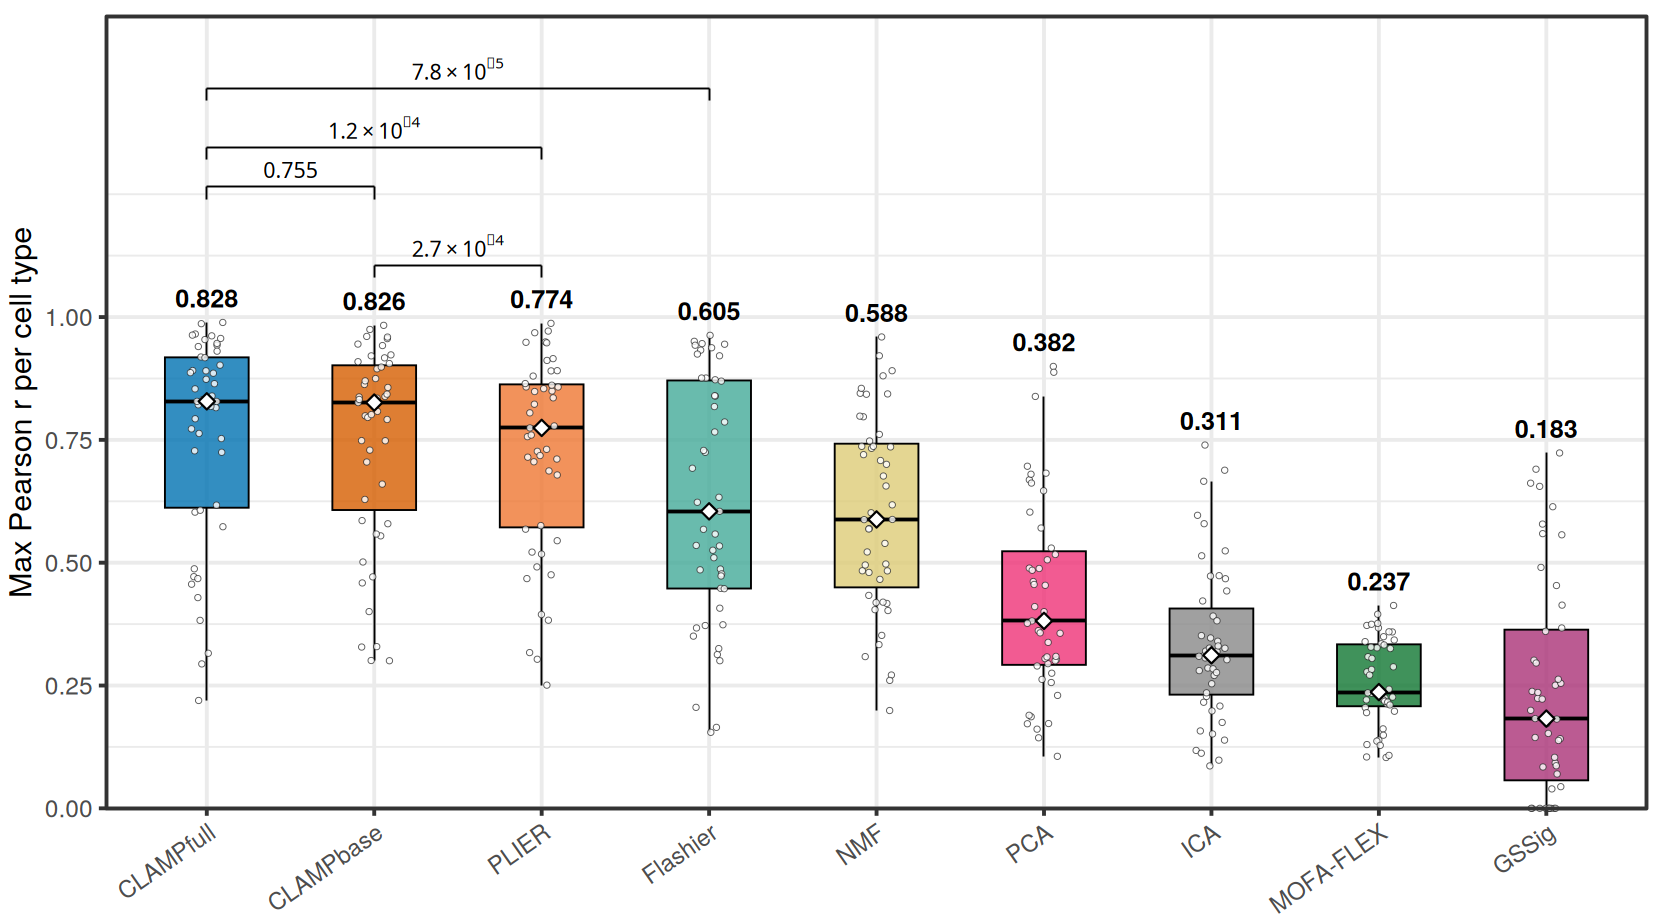

In [7]:
wide_ct_box <- dcast(long_box, dataset + cell_type ~ method, value.var = "cor")

comp_df_paired <- rbind(
  data.table(a = "CLAMPfull", b = other_methods[1:3]),
  data.table(a = "CLAMPbase", b = "PLIER")
)
comp_df_paired[, p_raw := mapply(function(a, b) {
  d <- wide_ct_box[!is.na(get(a)) & !is.na(get(b))]
  wilcox.test(d[[a]], d[[b]], paired = TRUE, alternative = "two.sided", exact = FALSE)$p.value
}, a, b)]
comp_df_paired[, q := p.adjust(p_raw, method = "BH")]

assign_bracket_tiers <- function(comp_df, xpos) {
  comp_ord <- copy(comp_df)
  comp_ord[, x1 := xpos[a]]
  comp_ord[, x2 := xpos[b]]
  comp_ord[, left  := pmin(x1, x2)]
  comp_ord[, right := pmax(x1, x2)]
  comp_ord[, span  := right - left]
  setorder(comp_ord, span, q)

  levels_used <- list()
  comp_ord[, tier := 0L]

  for (i in seq_len(nrow(comp_ord))) {
    left  <- comp_ord$left[i]
    right <- comp_ord$right[i]
    tier  <- 1

    repeat {
      current <- if (tier <= length(levels_used)) levels_used[[tier]] else NULL
      overlaps <- FALSE

      if (!is.null(current)) {
        overlaps <- any(vapply(current, function(interval) {
          !(right < interval[1] || left > interval[2])
        }, logical(1)))
      }

      if (!overlaps) break
      tier <- tier + 1
    }

    comp_ord$tier[i] <- tier
    prior <- if (tier <= length(levels_used)) levels_used[[tier]] else list()
    levels_used[[tier]] <- c(prior, list(c(left, right)))
  }

  comp_ord
}

comp_ord <- assign_bracket_tiers(comp_df_paired, xpos)

n_tiers <- max(comp_ord$tier)
y_base  <- 1.08
y_step  <- 0.12
h       <- 0.025
y_max   <- y_base + (n_tiers - 1) * y_step + 0.14

options(repr.plot.width = 14, repr.plot.height = 7.7)

p_box_paired <- ggplot(long_box, aes(method, cor, fill = method)) +
  geom_boxplot(width = 0.5, outlier.shape = NA, color = "black",
               linewidth = 0.4, alpha = 0.8) +
  geom_jitter(width = 0.10, size = 1.3, shape = 21, fill = "white",
              color = "#333333", stroke = 0.3, alpha = 0.8) +
  geom_point(data = med_df, aes(x = method, y = median_cor), shape = 23,
             size = 3.2, fill = "white", color = "black", stroke = 0.7,
             inherit.aes = FALSE) +
  geom_text(data = med_df,
            aes(x = method, y = max_cor + 0.05, label = sprintf("%.3f", median_cor)),
            size = 5.2, fontface = "bold", inherit.aes = FALSE) +
  scale_fill_manual(values = METHOD_COLORS, na.value = "grey70") +
  scale_y_continuous(breaks = seq(0, 1, 0.25), expand = expansion(mult = c(0, 0.02))) +
  coord_cartesian(ylim = c(0, y_max), clip = "off") +
  labs(x = NULL, y = "Max Pearson r per cell type") +
  box_theme +
  theme(plot.margin = margin(10, 20, 5.5, 5.5))

for (i in seq_len(nrow(comp_ord))) {
  row <- comp_ord[i, ]
  y   <- y_base + (row$tier - 1) * y_step

  if (
    (row$a == "CLAMPfull" & row$b == "CLAMPbase") |
    (row$a == "CLAMPbase" & row$b == "CLAMPfull")
  ) {
    y <- y + 0.04
  }

  lbl <- fmt_q(row$q)

  p_box_paired <- p_box_paired +
    annotate("segment", x = row$left,  xend = row$left,  y = y,       yend = y + h, linewidth = 0.4) +
    annotate("segment", x = row$left,  xend = row$right, y = y + h, yend = y + h, linewidth = 0.4) +
    annotate("segment", x = row$right, xend = row$right, y = y,       yend = y + h, linewidth = 0.4) +
    annotate("text",
             x = (row$left + row$right) / 2,
             y = y + h + 0.018,
             label = lbl,
             size = 4.4,
             vjust = 0,
             parse = TRUE,
             family = "sans")
}

print(p_box_paired)

In [8]:
cat("Paired CLAMPfull vs. top-3 competitors (Wilcoxon signed-rank, two-sided, BH-adjusted):\n")
print(comp_df_paired[, .(a, b, p_raw, q)])

cat("\nPaired CLAMPfull vs. competitor (Hodges-Lehmann effect size + 95% CI), all competitors:\n")
print(paired_stats)

Paired CLAMPfull vs. top-3 competitors (Wilcoxon signed-rank, two-sided, BH-adjusted):


           a         b        p_raw            q
      <char>    <char>        <num>        <num>
1: CLAMPfull CLAMPbase 7.549085e-01 7.549085e-01
2: CLAMPfull     PLIER 6.192649e-05 1.238530e-04
3: CLAMPfull  Flashier 1.955597e-05 7.822389e-05
4: CLAMPbase     PLIER 1.995158e-04 2.660211e-04



Paired CLAMPfull vs. competitor (Hodges-Lehmann effect size + 95% CI), all competitors:


      method n_pairs  median_diff  hl_estimate       ci_low    ci_high
      <char>   <int>        <num>        <num>        <num>      <num>
1:     GSSig      47  0.498138607 0.5202682676  0.431369424 0.60579472
2: MOFA-FLEX      47  0.562825413 0.5200142935  0.424972856 0.59264749
3:       ICA      47  0.452358421 0.4252788789  0.359600448 0.49351013
4:       PCA      47  0.311694257 0.3368107850  0.263851565 0.40994481
5:       NMF      47  0.153645400 0.1489713660  0.105862874 0.19165665
6:  Flashier      47  0.115137976 0.1275630883  0.073825958 0.18309577
7:     PLIER      47  0.034510653 0.0325512716  0.017800383 0.04482127
8: CLAMPbase      47 -0.002598165 0.0009724208 -0.007534161 0.01274234
    p_two_sided      q_value
          <num>        <num>
1: 2.475780e-09 6.602081e-09
2: 2.475780e-09 6.602081e-09
3: 2.475780e-09 6.602081e-09
4: 7.331475e-09 1.466295e-08
5: 7.406180e-08 1.184989e-07
6: 1.955597e-05 2.607463e-05
7: 6.192649e-05 7.077313e-05
8: 7.549085e-01 7.549085e-01


### Bootstrap ranking stability

A dataset-level (cluster) bootstrap: resample the datasets with replacement,
average each method's per-cell-type cor within the resampled datasets, and record
which method comes out on top. Repeated over many resamples this gives a win rate
per method, a direct answer to "how often does CLAMPfull actually rank first?"

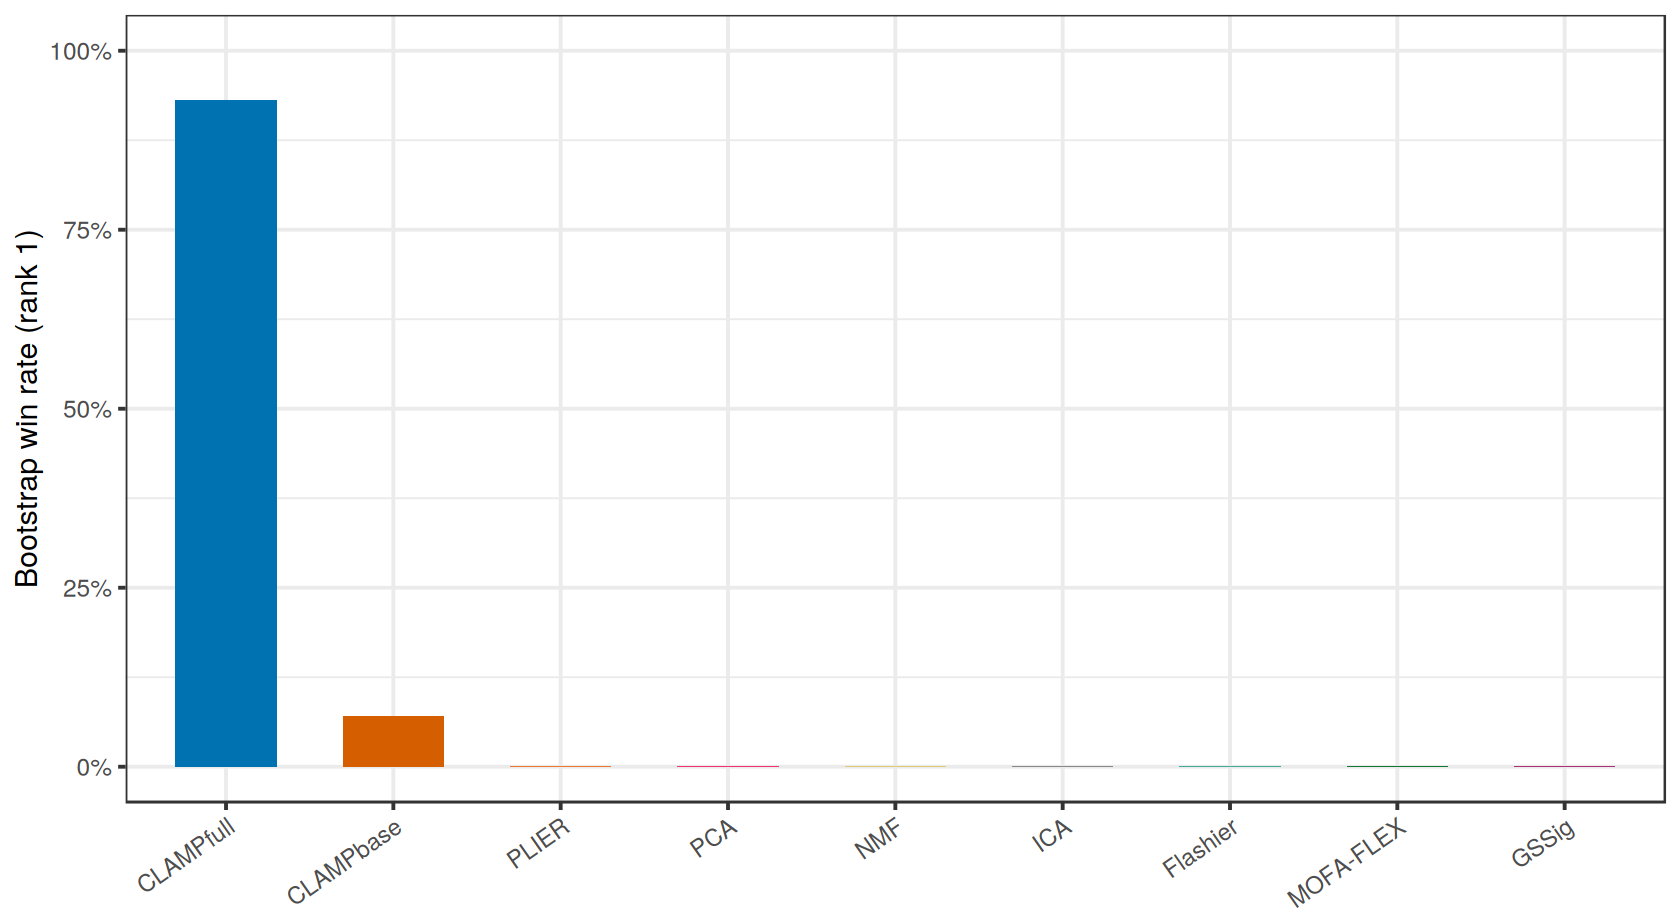

In [9]:
# Cluster (dataset-level) bootstrap: cell types within a dataset aren't
# independent draws, so resample whole datasets rather than individual cell
# types, then check how often CLAMPfull has the top mean cor.
set.seed(123)
n_boot <- 2000
methods_boot <- names(METHODS)

ds_method_mean <- long[truth == "v0" & !is.na(cor), .(mean_cor = mean(cor)), by = .(dataset, method)]
ds_method_wide <- dcast(ds_method_mean, dataset ~ method, value.var = "mean_cor")
n_ds <- nrow(ds_method_wide)

win_counts <- setNames(rep(0L, length(methods_boot)), methods_boot)
for (b in seq_len(n_boot)) {
  samp <- ds_method_wide[sample.int(n_ds, size = n_ds, replace = TRUE)]
  method_means <- vapply(methods_boot, function(m) mean(samp[[m]], na.rm = TRUE), numeric(1))
  top_method <- names(which.max(method_means))
  win_counts[top_method] <- win_counts[top_method] + 1L
}
win_rate <- data.table(method = names(win_counts), win_rate = as.numeric(win_counts) / n_boot)
setorder(win_rate, -win_rate)
win_rate[, method := factor(method, levels = method)]

options(repr.plot.width = 14, repr.plot.height = 7.7)
p_winrate <- ggplot(win_rate, aes(method, win_rate, fill = method)) +
    geom_col(width = 0.6) +
    scale_fill_manual(values = METHOD_COLORS) +
    scale_y_continuous(labels = function(x) paste0(x * 100, "%"), limits = c(0, 1)) +
    labs(x = NULL, y = "Bootstrap win rate (rank 1)") +
    box_theme
print(p_winrate)

In [10]:
cat(sprintf("Bootstrap win rate over %d dataset-level resamples:\n", n_boot))
print(win_rate)

Bootstrap win rate over 2000 dataset-level resamples:


      method win_rate
      <fctr>    <num>
1: CLAMPfull     0.93
2: CLAMPbase     0.07
3:     PLIER     0.00
4:       PCA     0.00
5:       NMF     0.00
6:       ICA     0.00
7:  Flashier     0.00
8: MOFA-FLEX     0.00
9:     GSSig     0.00


## Save outputs

All tables and figures computed above, written together here.

In [11]:
FIG2_DIR <- file.path(OUT_DIR, "fig2_export")
dir.create(FIG2_DIR, recursive = TRUE, showWarnings = FALSE)

fwrite(long,           file.path(OUT_DIR, "benchmark_long.csv"))
fwrite(summary_dt,     file.path(OUT_DIR, "benchmark_summary.csv"))
fwrite(lv_assignments, file.path(OUT_DIR, "clampfull_lv_assignments.csv"))
fwrite(lv_corr_full[, .(dataset, LV, cell_type, cor)],
       file.path(OUT_DIR, "clampfull_lv_ct_corr_full.csv"))
fwrite(long, file.path(FIG2_DIR, "benchmark_long.csv"))  # tmp-only fig2-style export

fwrite(comp_df_paired[, .(a, b, p_raw, q)], file.path(OUT_DIR, "paired_top3_bracket_qvalues.csv"))
fwrite(paired_stats, file.path(OUT_DIR, "paired_wilcoxon_effect_sizes.csv"))
fwrite(win_rate,     file.path(OUT_DIR, "bootstrap_winrate.csv"))

# ggsave() rather than the inline plots above: Jupyter's renderer can
# mis-render the plotmath minus sign in the q-value labels.
ggsave(file.path(OUT_DIR, "pseudobulk_benchmark_paired.png"), p_box_paired,
       width = 14, height = 7.7, dpi = 300, bg = "white")
ggsave(file.path(OUT_DIR, "bootstrap_winrate.png"), p_winrate,
       width = 14, height = 7.7, dpi = 300, bg = "white")

cat("Saved all outputs to", OUT_DIR, "\n")

Saved all outputs to /home/msubirana/Documents/pivlab/clamp-analyses/output/03_model_biology/02_pseudobulk/00_benchmark 
